# Eksperimen SML — Klasifikasi Kultivar Anggur (Wine Recognition)

**Nama siswa:** Bimo Bramantyo  
**Kelas:** Membangun Sistem Machine Learning — Proyek Akhir (Kriteria 1)

Notebook ini merupakan tahap **eksperimen manual** sebelum otomatisasi. Dataset yang digunakan adalah *Wine recognition* (178 sampel, 13 fitur hasil analisis kimia, dan 3 kelas kultivar anggur `0/1/2`). Alur mengikuti Template Eksperimen MSML: **Import Library → Data Loading → EDA → Data Preprocessing → Menyimpan dataset siap latih**.

> Catatan desain: standardisasi fitur **tidak** disimpan ke berkas hasil preprocessing, melainkan ditanam di dalam `Pipeline` model (StandardScaler + SVC) pada tahap Kriteria 2. Berkas `wine_preprocessing.csv` berisi fitur bersih berskala asli agar layanan inferensi cukup menerima nilai pengukuran apa adanya.

## 1. Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid', palette='deep')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
print('Library siap.')

Library siap.


## 2. Data Loading

Membaca berkas mentah `wine_raw.csv` (disusun dari dataset *Wine recognition* bawaan scikit-learn) lalu memeriksa dimensi, tipe data, dan cuplikan awal.

In [2]:
df_mentah = pd.read_csv('../wine_raw.csv')
print('Dimensi data mentah:', df_mentah.shape)
df_mentah.head()

Dimensi data mentah: (178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [3]:
df_mentah.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

## 3. Exploratory Data Analysis (EDA)

### 3.1 Ringkasan statistik fitur

In [4]:
df_mentah.describe().T

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


### 3.2 Distribusi kelas kultivar
Memastikan proporsi tiap kultivar agar tahu apakah data relatif seimbang.

target
0    59
1    71
2    48
Name: count, dtype: int64

Proporsi (%):
target
0    33.15
1    39.89
2    26.97
Name: count, dtype: float64


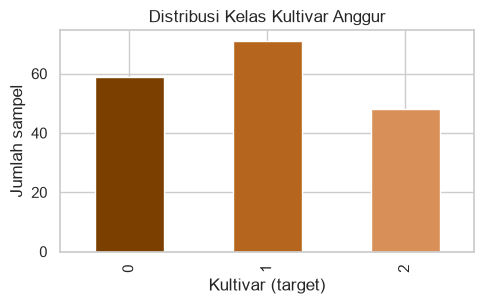

In [5]:
jumlah_kelas = df_mentah['target'].value_counts().sort_index()
print(jumlah_kelas)
print('\nProporsi (%):')
print((jumlah_kelas / len(df_mentah) * 100).round(2))

ax = jumlah_kelas.plot(kind='bar', color=['#7b3f00', '#b5651d', '#d99058'], figsize=(5, 3.2))
ax.set_title('Distribusi Kelas Kultivar Anggur')
ax.set_xlabel('Kultivar (target)')
ax.set_ylabel('Jumlah sampel')
plt.tight_layout()
plt.show()

### 3.3 Pemeriksaan duplikat dan nilai kosong
Dataset numerik ini perlu dicek keberadaan baris ganda dan sel kosong sebelum masuk tahap pemodelan.

In [6]:
print('Jumlah baris duplikat :', int(df_mentah.duplicated().sum()))
print('Total nilai kosong    :', int(df_mentah.isna().sum().sum()))
df_mentah.isna().sum()

Jumlah baris duplikat : 0
Total nilai kosong    : 0


alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

### 3.4 Korelasi antar fitur
Peta korelasi membantu mengenali pasangan fitur yang saling berkaitan kuat (mis. `flavanoids` dengan `total_phenols`).

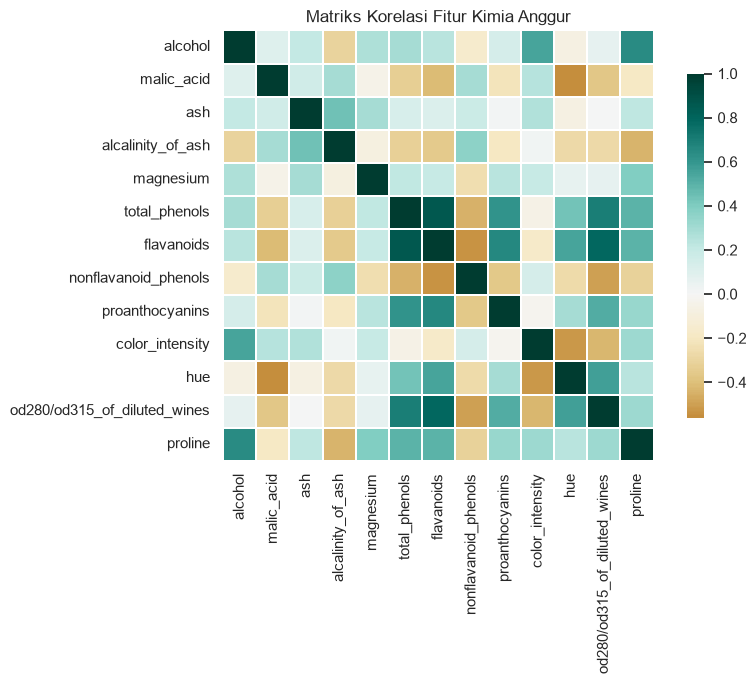

In [7]:
plt.figure(figsize=(9, 7))
korelasi = df_mentah.drop(columns=['target']).corr()
sns.heatmap(korelasi, cmap='BrBG', center=0, square=True,
            cbar_kws={'shrink': 0.8}, linewidths=0.3)
plt.title('Matriks Korelasi Fitur Kimia Anggur')
plt.tight_layout()
plt.show()

### 3.5 Sebaran fitur kunci terhadap kultivar
Boxplot beberapa fitur pembeda memperlihatkan bahwa kultivar dapat dipisahkan berdasarkan komposisi kimianya.

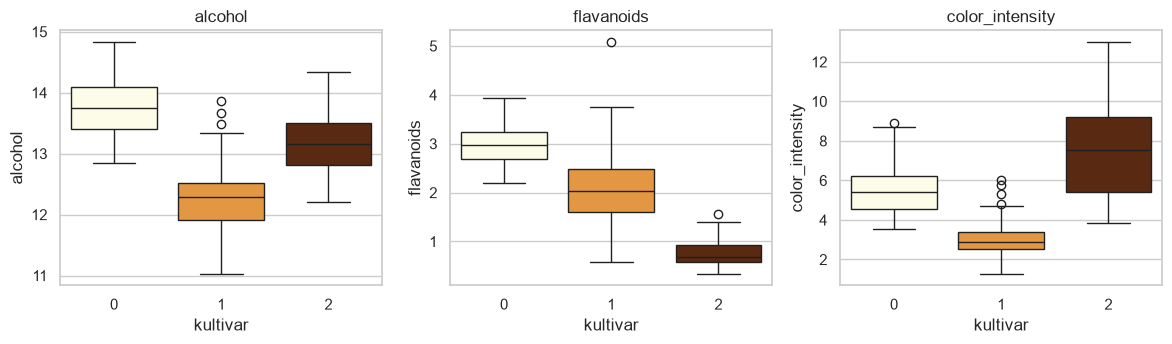

In [8]:
fitur_kunci = ['alcohol', 'flavanoids', 'color_intensity']
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, kol in zip(axes, fitur_kunci):
    sns.boxplot(data=df_mentah, x='target', y=kol, ax=ax, hue='target',
                palette='YlOrBr', legend=False)
    ax.set_title(kol)
    ax.set_xlabel('kultivar')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

### 4.1 Merapikan nama kolom
Beberapa nama kolom mengandung karakter tak ramah (mis. `/`). Kolom dinormalkan menjadi `snake_case` yang aman dipakai lintas alat.

In [9]:
def rapikan_nama(nama: str) -> str:
    return (nama.strip().lower()
            .replace('/', '_').replace(' ', '_').replace('-', '_'))

df = df_mentah.rename(columns={c: rapikan_nama(c) for c in df_mentah.columns})
print('Nama kolom setelah dirapikan:')
print(list(df.columns))

Nama kolom setelah dirapikan:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280_od315_of_diluted_wines', 'proline', 'target']


### 4.2 Menghapus baris duplikat
Baris identik dibuang agar tidak membiaskan pelatihan (dataset asli bersih, langkah ini tetap dijalankan sebagai pengaman).

In [10]:
sebelum = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f'Baris sebelum: {sebelum}  ->  sesudah hapus duplikat: {len(df)}')

Baris sebelum: 178  ->  sesudah hapus duplikat: 178


### 4.3 Menyiapkan kolom target
Kolom `target` (0/1/2) diberi nama eksplisit `target_kultivar` agar makna kelas jelas pada berkas hasil dan proses serving.

In [11]:
df = df.rename(columns={'target': 'target_kultivar'})
df['target_kultivar'] = df['target_kultivar'].astype(int)
print('Kelas target:', sorted(df['target_kultivar'].unique()))
df[['target_kultivar']].value_counts().sort_index()

Kelas target: [np.int64(0), np.int64(1), np.int64(2)]


target_kultivar
0                  59
1                  71
2                  48
Name: count, dtype: int64

### 4.4 Demonstrasi standardisasi fitur
Fitur kimia berada pada rentang yang sangat berbeda (mis. `proline` ratusan vs `hue` di sekitar 1). Di bawah ini dibuktikan efek `StandardScaler` (rata-rata ≈ 0, simpangan baku ≈ 1). Scaler **tidak** ikut disimpan; ia akan menjadi bagian `Pipeline` model pada Kriteria 2 sehingga layanan inferensi tetap menerima nilai pengukuran asli.

In [12]:
kolom_fitur = [c for c in df.columns if c != 'target_kultivar']
peraga = StandardScaler().fit_transform(df[kolom_fitur])
peraga = pd.DataFrame(peraga, columns=kolom_fitur)
ringkas = pd.DataFrame({
    'mean_asli': df[kolom_fitur].mean().round(2),
    'std_asli': df[kolom_fitur].std().round(2),
    'mean_skala': peraga.mean().round(2),
    'std_skala': peraga.std().round(2),
})
ringkas

,mean_asli,std_asli,mean_skala,std_skala
alcohol,13.00,0.81,-0.0,1.0
malic_acid,2.34,1.12,-0.0,1.0
ash,2.37,0.27,-0.0,1.0
alcalinity_of_ash,19.49,3.34,-0.0,1.0
magnesium,99.74,14.28,-0.0,1.0
total_phenols,2.30,0.63,0.0,1.0
flavanoids,2.03,1.00,-0.0,1.0
nonflavanoid_phenols,0.36,0.12,0.0,1.0
proanthocyanins,1.59,0.57,-0.0,1.0
color_intensity,5.06,2.32,0.0,1.0


### 4.5 Pembagian data latih dan uji
Split 80:20 dengan `stratify` menjaga proporsi kultivar tetap sama di kedua subset. `random_state=17` dipakai konsisten sepanjang proyek.

In [13]:
X = df[kolom_fitur]
y = df['target_kultivar']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=17, stratify=y)
print('Latih:', X_train.shape, '| Uji:', X_test.shape)
print('\nProporsi kelas latih:')
print((y_train.value_counts(normalize=True).sort_index() * 100).round(1))
print('\nProporsi kelas uji:')
print((y_test.value_counts(normalize=True).sort_index() * 100).round(1))

Latih: (142, 13) | Uji: (36, 13)

Proporsi kelas latih:
target_kultivar
0    33.1
1    40.1
2    26.8
Name: proportion, dtype: float64

Proporsi kelas uji:
target_kultivar
0    33.3
1    38.9
2    27.8
Name: proportion, dtype: float64


### 4.6 Data akhir siap latih
Menggabungkan kembali fitur bersih dengan target untuk disimpan sebagai satu berkas yang siap dipakai skrip pemodelan otomatis (Kriteria 2 & 3).

In [14]:
df_siap = df[kolom_fitur + ['target_kultivar']].copy()
print('Dimensi akhir:', df_siap.shape)
df_siap.head()

Dimensi akhir: (178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315_of_diluted_wines,proline,target_kultivar
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## 5. Menyimpan Dataset Siap Latih

In [15]:
berkas_keluar = 'wine_preprocessing.csv'
df_siap.to_csv(berkas_keluar, index=False)
print(f'Tersimpan: {berkas_keluar}  ({df_siap.shape[0]} baris x {df_siap.shape[1]} kolom)')
print('Kolom:', list(df_siap.columns))

Tersimpan: wine_preprocessing.csv  (178 baris x 14 kolom)
Kolom: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280_od315_of_diluted_wines', 'proline', 'target_kultivar']
